# Hochschule Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/059vymd37' -- 'Hochschule Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, O...",https://openalex.org/W4283260917
1,not assigned,Hochschule Osnabrück,Faculty of Agricultural Sciences and Landscape...,https://openalex.org/W4280617268
2,not assigned,Hochschule Osnabrück,"University of Applied Sciences Osnabrueck, Ger...",https://openalex.org/W4205671236
3,not assigned,Hochschule Osnabrück,"University of Applied Sciences, Albrechtstrase...",https://openalex.org/W4294218419
4,not assigned,Hochschule Osnabrück,"University of Applied Sciences, Osnabruck , Ge...",https://openalex.org/W4294218419


In [33]:
MAPPING_DICT = {
    'Department für Duale Studiengänge (DDS)': ['duale studiengänge'],
    'Fakultät Management, Kultur und Technik': ['faculty of management', '(management|kultur) (und|and) (techn(ik|ology)|kultur)'],
    #'Institut für Kommunikationsmanagement': [],
    #'Institut für Theaterpädagogik': [],
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': ['agrarwissenschaften', 'agricultur(e|al)', 'horticultural', 'poultry', 'pflanzenschutz', 'ecology',
                                                                'nutrition', 'plant breeding', 'pflanzenernährung', 'landwirtschaftlich', 'tierhaltung'
                                                               ],
    'Fakultät Ingenieurwissenschaften und Informatik': ['computer (science|engineering)', 'material(s)? design', 'ingenieurwissenschaften', 'chemistry',
                                                        'verfahrenstechnik', 'thermodynamik', 'plastics'
                                                       ],
    'Fakultät Wirtschafts- und Sozialwissenschaften': ['social (science|studies)', 'sozialwissenschaft(t)?en', 'economic sciences', 'physical therapy',
                                                       'wirtschaftspsychologie'
                                                      ],
    #'Forschungszentrum Energiewirtschaft Energierecht (FEE)': [],
    'Forschungszentrum für Gesundheits- und Sozialinformatik': ['health informatics', 'social informatics'], # selbst ergänzt
    #'Institut für Musik': [],
    #'Kompetenzzentrum Globale Kompetenz': []
}

In [34]:
with open('./mapping_tables_fak/hsosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [35]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [36]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [37]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, O...",https://openalex.org/W4283260917
1,Fakultät Agrarwissenschaften und Landschaftsar...,Hochschule Osnabrück,Faculty of Agricultural Sciences and Landscape...,https://openalex.org/W4280617268
2,None,Hochschule Osnabrück,"University of Applied Sciences Osnabrueck, Ger...",https://openalex.org/W4205671236
3,None,Hochschule Osnabrück,"University of Applied Sciences, Albrechtstrase...",https://openalex.org/W4294218419
4,None,Hochschule Osnabrück,"University of Applied Sciences, Osnabruck , Ge...",https://openalex.org/W4294218419
...,...,...,...,...
1022,Fakultät Wirtschafts- und Sozialwissenschaften,Hochschule Osnabrück,Faculty of Business Administration and Social ...,https://openalex.org/W4319656446
1023,"Fakultät Management, Kultur und Technik",Hochschule Osnabrück,"Faculty of Management, Culture and Technology ...",https://openalex.org/W4319656446
1024,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Institute of Computer Engineering, Osnabrück U...",https://openalex.org/W4390017994
1025,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Sciences, ...",https://openalex.org/W3106433869


In [38]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[20:]

array(['Hochschule Osnabrck Albrechtstr. 30 49076 Osnabrck Deutschland',
       'Osnabrück University of Applied Sciences, Lingen (Ems), Germany',
       'Osnabrück University of Applied Sciences, Osnabrück, Germany',
       'Osnabrück University of Applied Sciences',
       'Hochschule Osnabrück - University of Applied Sciences, Albrechtstr. 30, Osnabrück, 49076, Germany',
       'Hochschule Osnabrück, University of Applied Sciences, Albrechtstr. 30, 49076 Osnabrück',
       'Universität Osnabrück - University of Applied Sciences',
       'University of Applied Sciences Osnabrück, Albrechtstr. 30, 49076, Osnabrück, Germany',
       'Hochschule Osnabrück - University of Applied Sciences/University of Alberta',
       'Hochschule Osnabrück - University of Applied Sciences',
       'Federal University of São Carlos/Hochschule Osnabrück - University of Applied Science',
       'Osnabrück University of Applied Sciences 2 , Osnabrück, Germany',
       'Hochschule Osnabrück - University of A

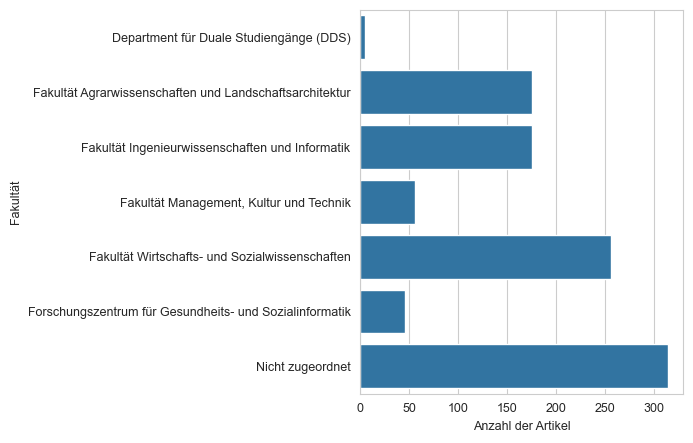

In [39]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [40]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6942551119766309

In [123]:
MAPPING_DICT_DEPT = {
    'Fakultät Management, Kultur und Technik': {},
    'Fakultät Agrarwissenschaften und Landschaftsarchitektur': {
        #'Abteilung Stadtplanung und Planungsrecht': [],
        'Bereich Pflanzenernährung und Pflanzenbau': ['plant (nutrition|breeding)'],
        #'Food Engineering - Lebensmitteltechnik': [],
        #'Forschungsschwerpunkt Agrar- und Ernährungssysteme, Landschafts- und Stadtentwicklung': [],
        #'Schwerpunkt Precision Livestock Farming': [],
    },
    'Fakultät Ingenieurwissenschaften und Informatik': {
        #'Fachbereich Technische Produktentwicklung': [],
        #'Labor Digitale Medien': [],
        'Labor für Angewandte Thermodynamik': ['thermodynami(k|c)'],
        'Labor für anorganische und analytische Chemie': ['chemi(e|stry)'],
        #'Labor für Digital- und Mikroprozessortechnik': [],
        'Labor für Fertigungsmesstechnik und Technisches Management': ['metrology'],
        #'Labor für Mikro- und Optoelektronik': [],
        #'Labor für Nachhaltige Energietechnik': [],
        #'Labor für Umformtechnik und Werkzeugmaschinen': [],
        'Labor für Verfahrenstechnik': ['verfahrenstechnik'],
        #'Laborbereich Fahrzeugtechnik': [],
        'Laborbereich Kunststofftechnik': ['plastics'],
        'Laborbereich Materialdesign und Werkstoffzuverlässigkeit': ['material(s)? design'],
        #'Medienlabor': [],
        #'Professur Konstruktion/CAD und Maschinenelemente': [],
        #'Studiengang Maschinenbau': [],
    },
    'Fakultät Wirtschafts- und Sozialwissenschaften': {}
}

In [124]:
with open('./mapping_tables_dept/hsosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [125]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [126]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät Ingenieurwissenschaften und Informatik')

In [127]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[20:]

array(['Faculty of Engineering and Computer Science, Osnabrück University of Applied Sciences, Albrechtstraße 30, 49076, Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Osnabrück University of Applied Sciences, Albrechtstr. 30, 49076 Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Material Science and Analysis, University of Applied Sciences Osnabrück, Albrechtstraße 30, 49076, Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Material Science and Analysis, University of Applied Sciences Osnabrück, Albrechtstraße 30, 49076 Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Dept. of Computer Science and Media, University of Applied Sciences, Osnabrück, Germany',
       'Faculty of Engineering and Computer Science, Osnabr&#x00FC;ck University of Applied Sciences, Osnabr&#x00FC;ck, Germany',
       'Faculty of Engineering and Computer Science, University of Applied Sciences Osnabrueck, 49009

In [128]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Labor für Angewandte Thermodynamik,1
1,Labor für Fertigungsmesstechnik und Technische...,1
2,Labor für Verfahrenstechnik,2
3,Labor für anorganische und analytische Chemie,13
4,Laborbereich Kunststofftechnik,2
5,Laborbereich Materialdesign und Werkstoffzuver...,31
6,NaN,125


In [129]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Ingenieurwissenschaften und Informatik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
0,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, O...",https://openalex.org/W4283260917,None
5,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W4292590378,None
10,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Sciences, ...",https://openalex.org/W4312065668,Laborbereich Materialdesign und Werkstoffzuver...
11,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Laboratory for Material Design and Structural ...,https://openalex.org/W4307290970,Laborbereich Materialdesign und Werkstoffzuver...
21,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Materials Design and Structural Integrity Labo...,https://openalex.org/W4292839972,Laborbereich Materialdesign und Werkstoffzuver...
...,...,...,...,...,...
1009,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W3123536791,None
1010,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,Institute of Materials Design and Structural I...,https://openalex.org/W3092221174,Laborbereich Materialdesign und Werkstoffzuver...
1018,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Faculty of Engineering and Computer Science, U...",https://openalex.org/W4411801130,None
1024,Fakultät Ingenieurwissenschaften und Informatik,Hochschule Osnabrück,"Institute of Computer Engineering, Osnabrück U...",https://openalex.org/W4390017994,None
